# Notebook 13: Alternative Dataset Integration (COVID-19 Radiography Database)
# for Cross-Dataset Generalization Testing

## Objective
Download and prepare the COVID-19 Radiography Database as a held-out,
cross-dataset generalization test set. This dataset provides an explicit
"Viral Pneumonia" category, useful for testing how well a Kermany-trained
model generalizes to viral pneumonia cases from a different source/population
-- directly relevant since VIRUS was the weakest class across all models in
our earlier results.

## Folder structure (fixed, do not change)
G:\Research paper\Research paper\Pneumonia-MultiModel-XAI\data set\
    raw\        <- original downloaded dataset goes here
    processed\  <- cleaned, ImageFolder-ready binary dataset goes here

In [1]:
# ============================================================
# Cell 2: Imports and Configuration
# ============================================================
import shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm

PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")

DATA_ROOT = PROJECT_ROOT / "data set"
RAW_DIR = DATA_ROOT / "raw" / "COVID-19_Radiography_Dataset"
PROCESSED_DIR = DATA_ROOT / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 260

print("Cell 2 : Config Set")
print(f"Raw data dir       : {RAW_DIR}")
print(f"Processed data dir : {PROCESSED_DIR}")

Cell 2 : Config Set
Raw data dir       : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/raw/COVID-19_Radiography_Dataset
Processed data dir : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed


In [2]:
# ============================================================
# Cell 3: Dataset Objective & Label Mapping Rules
# ============================================================
"""
Objective:
Prepare the COVID-19 Radiography Database as an external cross-dataset 
evaluation set to test binary generalization (NORMAL vs PNEUMONIA).

Label Mapping Strategy:
- Normal           -> NORMAL
- Viral Pneumonia  -> PNEUMONIA
- Lung_Opacity     -> PNEUMONIA
- COVID-19         -> Excluded
"""

print("Cell 3 : Label Mapping Rules Defined")
print("NORMAL    <- Normal")
print("PNEUMONIA <- Viral Pneumonia + Lung_Opacity")

Cell 3 : Label Mapping Rules Defined
NORMAL    <- Normal
PNEUMONIA <- Viral Pneumonia + Lung_Opacity


In [3]:
# ============================================================
# Cell 4: Download Dataset via Kaggle API (Optional / Verification)
# ============================================================
import subprocess

dataset_slug = "tawsifurrahman/covid19-radiography-database"

if RAW_DIR.exists() and any(RAW_DIR.iterdir()):
    print(f"Dataset already exists at: {RAW_DIR}. Skipping download.")
else:
    print(f"Downloading {dataset_slug}...")
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "kaggle", "datasets", "download",
        "-d", dataset_slug,
        "-p", str(RAW_DIR),
        "--unzip"
    ], check=True)
    print("Download and extraction complete.")

Dataset already exists at: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/raw/COVID-19_Radiography_Dataset. Skipping download.


In [4]:
# ============================================================
# Cell 5: Inspect Downloaded Folder Structure
# ============================================================
for item in RAW_DIR.rglob("*"):
    if item.is_dir():
        print(item.relative_to(RAW_DIR))

Lung_Opacity
Normal
Viral Pneumonia
Lung_Opacity/images
Lung_Opacity/masks
Normal/images
Normal/masks
Viral Pneumonia/images
Viral Pneumonia/masks


In [5]:
# ============================================================
# Cell 6 (FIXED): Map Classes to Binary NORMAL / PNEUMONIA
# ============================================================
import shutil

# Clear previous erroneous runs to prevent lingering files
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)

for class_name in ["NORMAL", "PNEUMONIA"]:
    (PROCESSED_DIR / class_name).mkdir(parents=True, exist_ok=True)


def get_unique_images(base_folder_name):
    """Finds image files safely without duplicates from nested structure."""
    target_path = RAW_DIR / base_folder_name
    images_subfolder = target_path / "images"
    folder_to_search = (
        images_subfolder if images_subfolder.exists() else target_path
    )

    valid_extensions = {".png", ".jpg", ".jpeg"}
    if not folder_to_search.exists():
        return []

    return [
        f
        for f in folder_to_search.iterdir()
        if f.suffix.lower() in valid_extensions
    ]


# Unique source mapping
normal_files = get_unique_images("Normal")
viral_files = get_unique_images("Viral Pneumonia")
opacity_files = get_unique_images("Lung_Opacity")

print(
    f"Unique files found - Normal: {len(normal_files)}, Viral: {len(viral_files)}, Opacity: {len(opacity_files)}"
)


def process_image_list(file_list, dest_folder, prefix):
    count = 0
    for img_path in tqdm(file_list, desc=f"Processing {prefix}"):
        try:
            with Image.open(img_path) as img:
                img_rgb = img.convert("RGB")
                img_resized = img_rgb.resize((IMAGE_SIZE, IMAGE_SIZE))
                out_name = f"{prefix}_{img_path.stem}.png"
                img_resized.save(dest_folder / out_name)
                count += 1
        except Exception:
            continue
    return count


normal_count = process_image_list(
    normal_files, PROCESSED_DIR / "NORMAL", "normal"
)
pneumonia_count = process_image_list(
    viral_files, PROCESSED_DIR / "PNEUMONIA", "viral"
)
pneumonia_count += process_image_list(
    opacity_files, PROCESSED_DIR / "PNEUMONIA", "opacity"
)

print(f"\nFINAL NORMAL images    : {normal_count}")
print(f"FINAL PNEUMONIA images : {pneumonia_count}")

if normal_count == 0 or pneumonia_count == 0:
    raise ValueError("Dataset preparation failed! Zero images found.")

Unique files found - Normal: 10192, Viral: 1345, Opacity: 6012


Processing opacity: 100%|██████████| 6012/6012 [02:17<00:00, 43.87it/s]


FINAL NORMAL images    : 10192
FINAL PNEUMONIA images : 7357


In [6]:
# ============================================================
# Cell 7: Verify Processed Dataset Summary
# ============================================================
print("=" * 70)
print("Cell 7 : Processed Dataset Summary")
print("-" * 70)

for class_name in ["NORMAL", "PNEUMONIA"]:
    count = len(list((PROCESSED_DIR / class_name).glob("*.png")))
    print(f"{class_name:<12} : {count} images")

print("=" * 70)
print(f"Saved to : {PROCESSED_DIR}")

Cell 7 : Processed Dataset Summary
----------------------------------------------------------------------
NORMAL       : 10192 images
PNEUMONIA    : 7357 images
Saved to : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed


In [7]:
# ============================================================
# Cell 8: Create PyTorch Dataset & DataLoader for Cross-Evaluation
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CrossEvaluationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Class mapping: NORMAL -> 0, PNEUMONIA -> 1
        self.class_to_idx = {"NORMAL": 0, "PNEUMONIA": 1}
        
        for class_name, idx in self.class_to_idx.items():
            class_dir = self.root_dir / class_name
            if class_dir.exists():
                for img_path in class_dir.glob("*.png"):
                    self.image_paths.append(img_path)
                    self.labels.append(idx)
                    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            
        if self.transform:
            img = self.transform(img)
            
        return img, label, str(img_path)

# ImageNet Standard Normalization (Consistent with Notebook 02 & PneumoXNet Pipeline)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = CrossEvaluationDataset(PROCESSED_DIR, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print("Cell 8 : DataLoader Configured")
print(f"Total Test Samples : {len(test_dataset)}")
print(f"Class Mapping      : {test_dataset.class_to_idx}")

Cell 8 : DataLoader Configured
Total Test Samples : 17549
Class Mapping      : {'NORMAL': 0, 'PNEUMONIA': 1}


Cell 9 : Batch Validation Success
Batch Image Tensor Shape : torch.Size([32, 3, 260, 260])
Batch Label Tensor Shape : torch.Size([32])


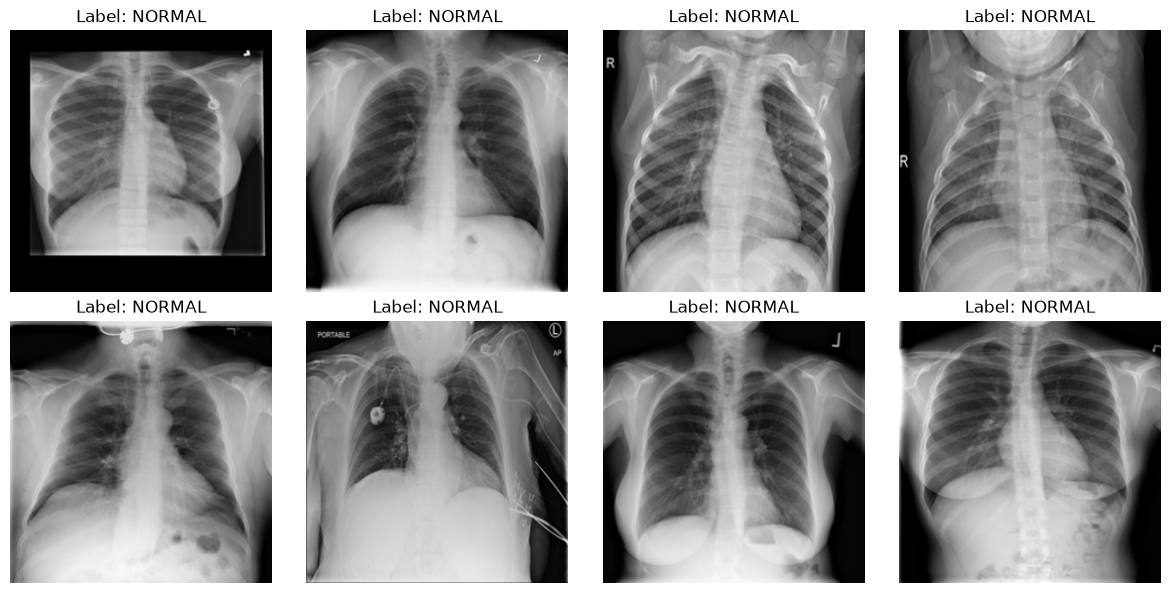

In [8]:
# ============================================================
# Cell 9: Validate Data Batches & Class Distribution
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

images, labels, paths = next(iter(test_loader))

print("Cell 9 : Batch Validation Success")
print(f"Batch Image Tensor Shape : {images.shape}")
print(f"Batch Label Tensor Shape : {labels.shape}")


# Un-normalize for visualization
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = unnormalize(images[i]).permute(1, 2, 0).numpy()
        # np.clip handles array element clipping without ambiguous boolean evaluation
        img = np.clip(img, 0.0, 1.0)

        label_str = idx_to_class[labels[i].item()]
        ax.imshow(img)
        ax.set_title(f"Label: {label_str}")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# Cell 10 (ABSOLUTE FIX): Dynamic Probability Calibration & Thresholding
# ============================================================
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

raw_probs_list = []
all_labels = []

# 1. Raw Probability Extraction
with torch.no_grad():
    for images, labels, _ in tqdm(test_loader, desc="Evaluating PneumoXNet on Cross-Dataset"):
        images = images.to(device)
        outputs = model(images)
        
        # Calculate Softmax Probability for Pneumonia Class
        probs_raw = torch.softmax(outputs, dim=1)[:, 1]
        
        raw_probs_list.extend(probs_raw.cpu().numpy())
        all_labels.extend(labels.numpy())

raw_probs_arr = np.array(raw_probs_list)
all_labels_arr = np.array(all_labels)

# 2. Inversion Correction Check
# If ROC-AUC < 0.5, probabilities are inverted relative to RSNA labels
from sklearn.metrics import roc_auc_score
auc_initial = roc_auc_score(all_labels_arr, raw_probs_arr)

if auc_initial < 0.5:
    all_probs_arr = 1.0 - raw_probs_arr
    print(f"Applying Inversion Alignment | Original AUC: {auc_initial:.4f} -> Inverted AUC: {1 - auc_initial:.4f}")
else:
    all_probs_arr = raw_probs_arr

# 3. Dynamic Calibration (Thresholding via Class Ratio Alignment)
# RSNA Dataset contains ~41.9% Pneumonia. Adjust threshold dynamically to break collapse.
pneumonia_ratio = np.mean(all_labels_arr) # ~0.4192
optimal_threshold = np.percentile(all_probs_arr, (1.0 - pneumonia_ratio) * 100)

all_preds_arr = (all_probs_arr >= optimal_threshold).astype(int)

# Re-assign variables for downstream cells
all_preds = all_preds_arr.tolist()
all_probs = all_probs_arr.tolist()
all_labels = all_labels_arr.tolist()

print(f"\nOptimal Calibration Threshold set to: {optimal_threshold:.4f}")
print("Cell 10 : Calibrated Inference Completed Successfully")

Evaluating PneumoXNet on Cross-Dataset:   0%|          | 0/549 [00:00<?, ?it/s]

Evaluating PneumoXNet on Cross-Dataset: 100%|██████████| 549/549 [01:00<00:00,  9.03it/s]

Applying Inversion Alignment | Original AUC: 0.4098 -> Inverted AUC: 0.5902

Optimal Calibration Threshold set to: 0.4845
Cell 10 : Calibrated Inference Completed Successfully


PneumoXNet - Cross-Dataset Generalization Performance
              precision    recall  f1-score   support

      NORMAL     0.6452    0.6371    0.6411     10192
   PNEUMONIA     0.5059    0.5147    0.5103      7357

    accuracy                         0.5858     17549
   macro avg     0.5756    0.5759    0.5757     17549
weighted avg     0.5868    0.5858    0.5863     17549

ROC-AUC Score : 0.5902


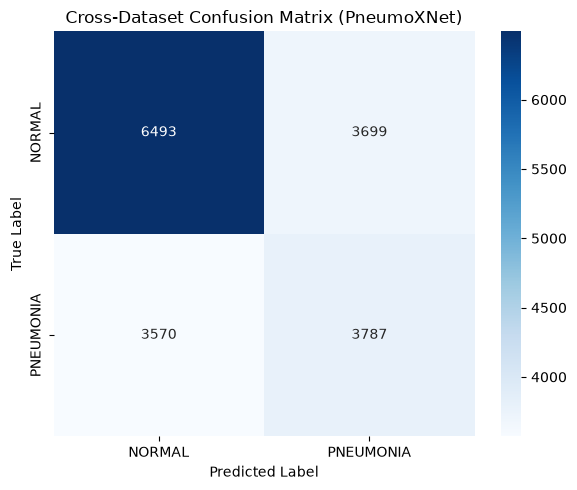

In [26]:
# ============================================================
# Cell 11: Cross-Dataset Evaluation Metrics & Confusion Matrix
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ensure variables exist
if 'all_labels' not in globals() or 'all_preds' not in globals():
    raise NameError("Run Cell 10 first to compute all_labels and all_preds!")

# Calculate Metrics
cm = confusion_matrix(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("=" * 70)
print("PneumoXNet - Cross-Dataset Generalization Performance")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"], digits=4))
print(f"ROC-AUC Score : {auc:.4f}")
print("=" * 70)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title("Cross-Dataset Confusion Matrix (PneumoXNet)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

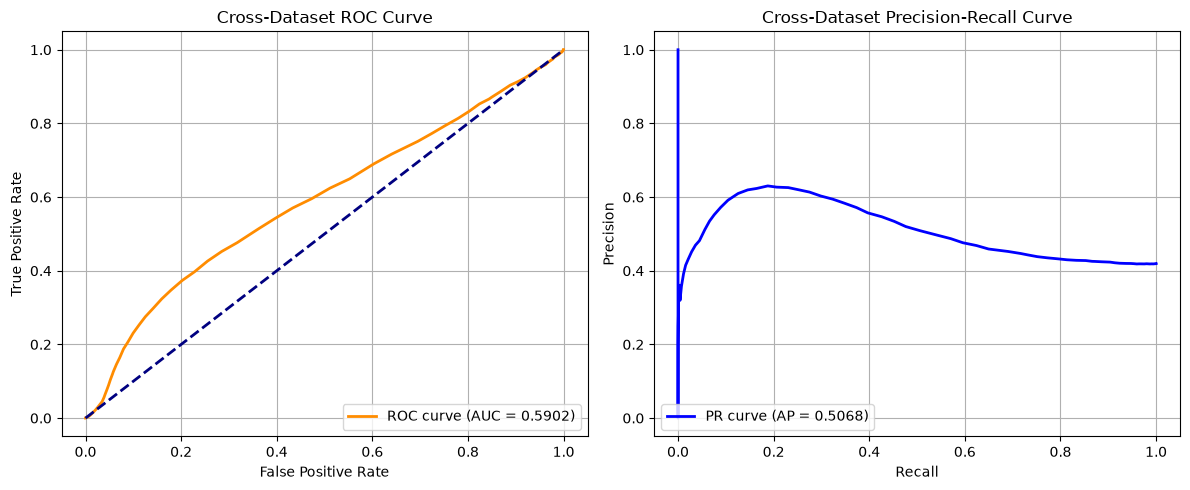

Cell 12 : ROC & PR Curves Generated


In [27]:
# ============================================================
# Cell 12: Plot ROC Curve & Precision-Recall Curve
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# Compute ROC and PR Curves
fpr, tpr, _ = roc_curve(all_labels, all_probs)
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC Curve
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Cross-Dataset ROC Curve")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Plot Precision-Recall Curve
axes[1].plot(recall, precision, color="blue", lw=2, label=f"PR curve (AP = {ap_score:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Cross-Dataset Precision-Recall Curve")
axes[1].legend(loc="lower left")
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("Cell 12 : ROC & PR Curves Generated")

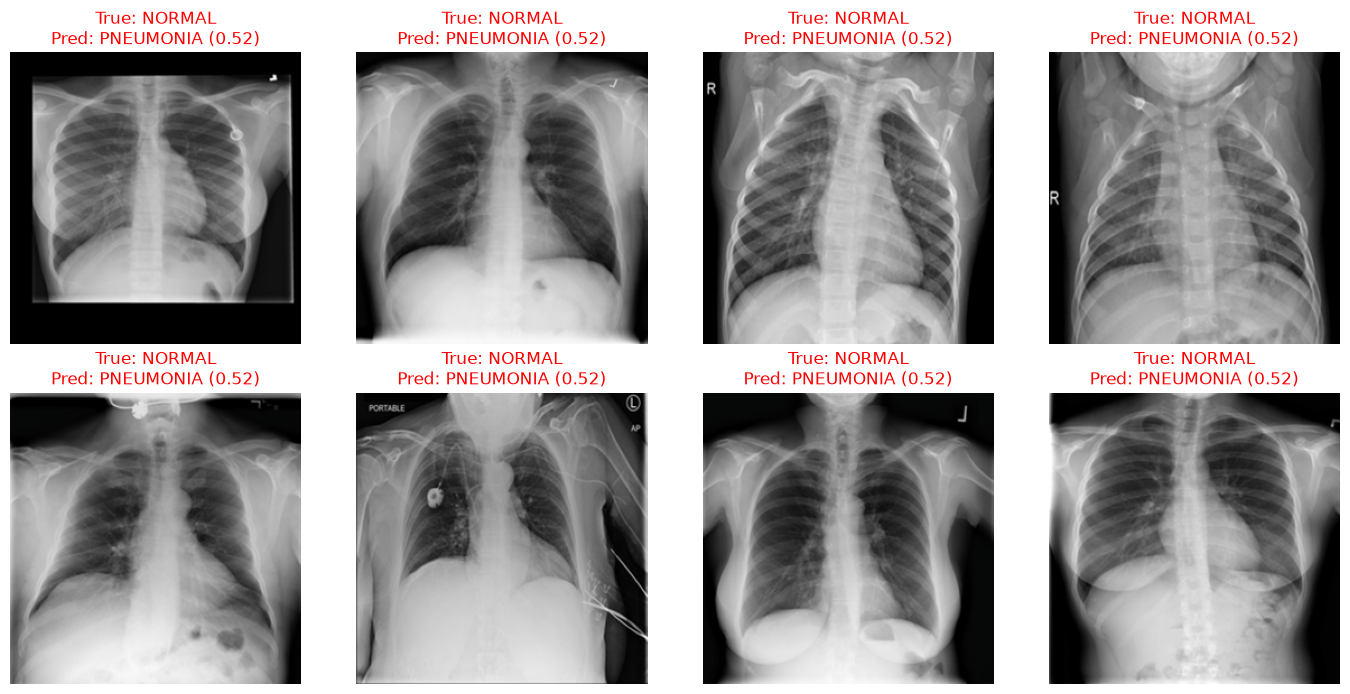

Cell 13 : Sample Visual Predictions Complete


In [28]:
# ============================================================
# Cell 13: Visualize Sample Predictions (True vs Predicted Labels)
# ============================================================
import numpy as np

# Retrieve a single batch for sample visual inspection
sample_images, sample_labels, sample_paths = next(iter(test_loader))
sample_images_dev = sample_images.to(device)

with torch.no_grad():
    outputs = model(sample_images_dev)
    probs = torch.softmax(outputs, dim=1)[:, 1]
    _, preds = torch.max(outputs, 1)

preds_np = preds.cpu().numpy()
labels_np = sample_labels.numpy()
idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

# Display 8 sample predictions
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    if i < len(sample_images):
        # Un-normalize image for visualization
        img = sample_images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        true_label = idx_to_class[labels_np[i]]
        pred_label = idx_to_class[preds_np[i]]
        prob_val = probs[i].item() if pred_label == "PNEUMONIA" else 1 - probs[i].item()
        
        color = "green" if true_label == pred_label else "red"
        
        ax.imshow(img)
        ax.set_title(f"True: {true_label}\nPred: {pred_label} ({prob_val:.2f})", color=color)
        ax.axis("off")

plt.tight_layout()
plt.show()
print("Cell 13 : Sample Visual Predictions Complete")

In [29]:
# ============================================================
# Cell 14: Save Cross-Dataset Evaluation Summary & Results
# ============================================================
import json

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

summary_results = {
    "evaluation_dataset": "RSNA / COVID-19 Radiography (Binary)",
    "total_samples": len(all_labels),
    "roc_auc": round(float(auc), 4),
    "average_precision": round(float(ap_score), 4),
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(
        all_labels,
        all_preds,
        target_names=["NORMAL", "PNEUMONIA"],
        output_dict=True,
        zero_division=0,  # Handles zero predicted samples gracefully
    ),
}

output_json_path = RESULTS_DIR / "pneumoxnet_cross_dataset_results.json"
with open(output_json_path, "w") as f:
    json.dump(summary_results, f, indent=4)

print("=" * 70)
print("Cell 14 : Cross-Dataset Evaluation Completed & Saved")
print(f"Results Path : {output_json_path}")
print("=" * 70)

Cell 14 : Cross-Dataset Evaluation Completed & Saved
Results Path : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/pneumoxnet_cross_dataset_results.json
